# ROMS Doppio and OOI Near-surface CTD

Revised May 21, 2026 by Sage Lichtenwalner

This notebook demonstrates how to compare CTD data from the [OOI Pioneer MAB Central Surface Mooring](https://oceanobservatories.org/site/cp10cnsm/) with model data from ROMS Doppio.  

For this example, we will grab OOI data from Erddap, and model data from Rutgers Threadds data server.  The Thredds server provides easy access to the large model dataset, however, data requests for large areas or time periods are not possible due to the limitations of processing on the Thredds site.

For this example we will use 1-year of dta (2025) from the Near-surface CTD.  The mooring also has CTDs available at the surface and bottom, though it is fairly shallow at 30m.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from erddapy import ERDDAP

## Load OOI Pioneer Data
First, we'll use erddapy to load near-surface CTD data from the Central Surface Mooring (via OOI's Data Explorer ERDDAP).

In [2]:
# OOI Pioneer CP10CNSM – Near Surface Instrument Frame CTD
server = 'https://erddap.dataexplorer.oceanobservatories.org/erddap'
dataset_id = 'ooi-cp10cnsm-rid27-03-ctdbpc000'

variables = [
    'time',
    'sea_water_temperature',
    'sea_water_practical_salinity',
    'latitude',
    'longitude',
]

constraints = {
    'time>=': '2025-01-01T00:00:00Z',
    'time<=': '2026-01-01T00:00:00Z',
}

e = ERDDAP(
    server=server,
    protocol='tabledap',
)
e.dataset_id = dataset_id
e.variables = variables
e.constraints = constraints

print(e.get_download_url(response='csvp'))

df_ooi = e.to_pandas(
    response='csv',
    parse_dates=True,
    skiprows=[1],
    index_col='time',
).dropna(how='all')

df_ooi.head()

https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-cp10cnsm-rid27-03-ctdbpc000.csvp?time,sea_water_temperature,sea_water_practical_salinity,latitude,longitude&time>=1735689600.0&time<=1767225600.0


,sea_water_temperature,sea_water_practical_salinity,latitude,longitude
time,,,,
2025-01-01 00:00:00+00:00,11.643658,33.373315,35.950317,-75.11953
2025-01-01 00:02:00+00:00,11.642210,33.360807,35.950317,-75.11953
2025-01-01 00:03:00+00:00,11.671196,33.411328,35.950317,-75.11953
2025-01-01 00:15:00+00:00,11.589437,33.270471,35.950317,-75.11953
2025-01-01 00:16:00+00:00,11.623095,33.331542,35.950317,-75.11953


<Axes: xlabel='time'>

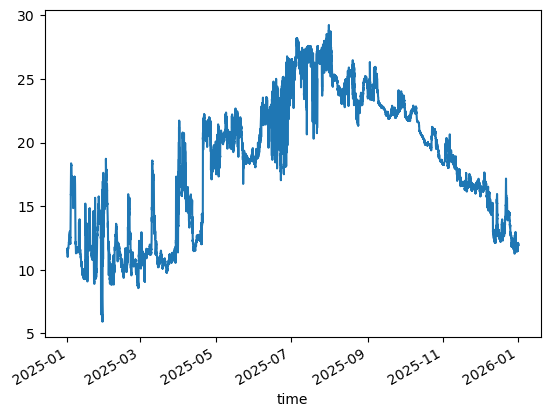

In [3]:
df_ooi['sea_water_temperature'].plot()

## Mooring Location
In order to extract the model data, we need to know the mooring location.  We could look this up, but it is also included in the Erddap dataset.  We'll use the median of the lat/lon values to get a single representative point.  (Though, the lat/lon seems to static in this case.)


In [4]:
ooi_lat = float(df_ooi['latitude'].median())
ooi_lon = float(df_ooi['longitude'].median())

print(f'OOI location: lat={ooi_lat:.4f}, lon={ooi_lon:.4f}')


OOI location: lat=35.9503, lon=-75.1195


## Load ROMS Data

In [5]:
doppio_url = 'https://tds.marine.rutgers.edu/thredds/dodsC/roms/doppio/2017_da/his/History_Best'
ds = xr.open_dataset(doppio_url)
ds

<xarray.Dataset> Size: 7TB
Dimensions:         (time: 75300, time1: 75300, time2: 480, time3: 75300,
                     tracer: 2, boundary: 4, s_rho: 40, s_w: 41, eta_rho: 106,
                     xi_rho: 242, eta_u: 106, xi_u: 241, eta_v: 105, xi_v: 242,
                     eta_psi: 105, xi_psi: 241, ocean_time: 25)
Coordinates: (12/18)
  * time            (time) datetime64[ns] 602kB 2017-11-02T01:00:00 ... 2026-...
    time_run        (time) datetime64[ns] 602kB ...
  * time1           (time1) datetime64[ns] 602kB 2017-11-02T01:00:00 ... 2026...
    time1_run       (time1) datetime64[ns] 602kB ...
  * time2           (time2) datetime64[ns] 4kB 2023-06-30T01:00:00 ... 2024-1...
  * time3           (time3) datetime64[ns] 602kB 2017-11-02T01:00:00 ... 2026...
    ...              ...
    lat_u           (eta_u, xi_u) float64 204kB ...
    lon_v           (eta_v, xi_v) float64 203kB ...
    lat_v           (eta_v, xi_v) float64 203kB ...
    lon_psi         (eta_psi, xi_psi) float64 202kB ...
    lat_psi         (eta_psi, xi_psi) float64 202kB ...
  * ocean_time      (ocean_time) datetime64[ns] 200B 2026-05-11 ... 2026-05-12
Dimensions without coordinates: tracer, boundary, eta_rho, xi_rho, eta_u, xi_u,
                                eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/123)
    time_offset     (time) datetime64[ns] 602kB ...
    time1_offset    (time1) datetime64[ns] 602kB ...
    time2_run       (time2) datetime64[ns] 4kB ...
    time2_offset    (time2) datetime64[ns] 4kB ...
    time3_offset    (time3) datetime64[ns] 602kB ...
    ntimes          int32 4B ...
    ...              ...
    sustr           (time1, eta_u, xi_u) float64 15GB ...
    svstr           (time1, eta_v, xi_v) float64 15GB ...
    v_northward_1m  (time, eta_rho, xi_rho) float64 15GB ...
    u_eastward_1m   (time, eta_rho, xi_rho) float64 15GB ...
    Vwind           (time, eta_rho, xi_rho) float64 15GB ...
    Uwind           (time, eta_rho, xi_rho) float64 15GB ...
Attributes: (12/49)
    file:                            doppio_his_7435_0001.nc
    format:                          netCDF-4/HDF5 file
    Conventions:                     CF-1.4, SGRID-0.3
    type:                            ROMS/TOMS history file
    title:                           ROMS doppio Real-Time Operational PSAS F...
    var_info:                        ../Data/varinfo1040t_daily.dat
    ...                              ...
    cdm_data_type:                   GRID
    featureType:                     GRID
    location:                        Proto fmrc:doppio_2017_da_his
    summary:                         doppio
    DODS_EXTRA.Unlimited_Dimension:  ocean_time
    EXTRA_DIMENSION.N:               40

In [6]:
print('\nDataset summary')
print(f'  Size:    {ds.nbytes/1e12:,.3f} TB')

print('Temperature summary')
temp_var = ds['temp']
print(f'  dims:        {temp_var.dims}')
print(f'  shape:       {temp_var.shape}')
print(f'  dtype:       {temp_var.dtype}')
print(f'  n_values:    {temp_var.size:,}')
print(f'  size:        {temp_var.nbytes/1e9:,.1f} GB')
print(f'  attrs:       {temp_var.attrs}')



Dataset summary
  Size:    6.512 TB
Temperature summary
  dims:        ('time', 's_rho', 'eta_rho', 'xi_rho')
  shape:       (75300, 40, 106, 242)
  dtype:       float64
  n_values:    77,263,824,000
  size:        618.1 GB
  attrs:       {'units': 'Celsius', 'long_name': 'potential temperature', 'time': 'ocean_time', 'grid': 'grid', 'location': 'face', 'field': 'temperature, scalar, series', '_ChunkSizes': array([  1,  20,  53, 121], dtype=int32), 'standard_name': 'sea_water_potential_temperature'}


In [7]:
ds['s_rho']

<xarray.DataArray 's_rho' (s_rho: 40)> Size: 320B
array([-0.9875, -0.9625, -0.9375, -0.9125, -0.8875, -0.8625, -0.8375, -0.8125,
       -0.7875, -0.7625, -0.7375, -0.7125, -0.6875, -0.6625, -0.6375, -0.6125,
       -0.5875, -0.5625, -0.5375, -0.5125, -0.4875, -0.4625, -0.4375, -0.4125,
       -0.3875, -0.3625, -0.3375, -0.3125, -0.2875, -0.2625, -0.2375, -0.2125,
       -0.1875, -0.1625, -0.1375, -0.1125, -0.0875, -0.0625, -0.0375, -0.0125])
Coordinates:
  * s_rho    (s_rho) float64 320B -0.9875 -0.9625 -0.9375 ... -0.0375 -0.0125
Attributes:
    units:                     
    long_name:                 S-coordinate at RHO-points
    valid_min:                 -1.0
    valid_max:                 0.0
    positive:                  up
    standard_name:             ocean_s_coordinate_g2
    formula_terms:             s: s_rho C: Cs_r eta: zeta depth: h depth_c: hc
    field:                     s_rho, scalar
    _CoordinateTransformType:  Vertical
    _CoordinateAxisType:       GeoZ
    _CoordinateZisPositive:    up
    _CoordinateAxes:           s_rho

In [8]:
# Step 1: Find nearest ROMS grid point to OOI mooring.
lon2d = ds['lon_rho']
lat2d = ds['lat_rho']
dist2 = (lon2d - ooi_lon) ** 2 + (lat2d - ooi_lat) ** 2
eta_idx, xi_idx = np.unravel_index(np.nanargmin(dist2.values), dist2.shape)

grid_lat = float(lat2d.isel(eta_rho=eta_idx, xi_rho=xi_idx).values)
grid_lon = float(lon2d.isel(eta_rho=eta_idx, xi_rho=xi_idx).values)

print(f'Nearest grid index: eta={eta_idx}, xi={xi_idx}')
print(f'Nearest grid lat/lon: {grid_lat:.4f}, {grid_lon:.4f}')

# Step 2: Get bathymetric depth (h) at the nearest ROMS rho-grid point.
point_depth_m = float(ds['h'].isel(eta_rho=eta_idx, xi_rho=xi_idx).values)
point_mask = int(ds['mask_rho'].isel(eta_rho=eta_idx, xi_rho=xi_idx).values)

print(f'Bathymetric depth at nearest grid point: {point_depth_m:.2f} m')
print(f'Land/sea mask at point (1=ocean, 0=land): {point_mask}')

# Step 3: Get the s_rho index corresponding surface (min) or bottom (max).
s_rho_idx_min = ds['s_rho'].min().values
s_rho_idx_max = ds['s_rho'].max().values

s_rho_idx = s_rho_idx_min  # Choose surface (min) or bottom (max) as needed
print(f'Choosen s_rho value: {s_rho_idx}')

print(f'Chosen s_rho value times depth: {s_rho_idx * point_depth_m:.2f}')

Nearest grid index: eta=45, xi=38
Nearest grid lat/lon: 35.9569, -75.1586
Bathymetric depth at nearest grid point: 31.03 m
Land/sea mask at point (1=ocean, 0=land): 1
Choosen s_rho value: -0.9875
Chosen s_rho value times depth: -30.64


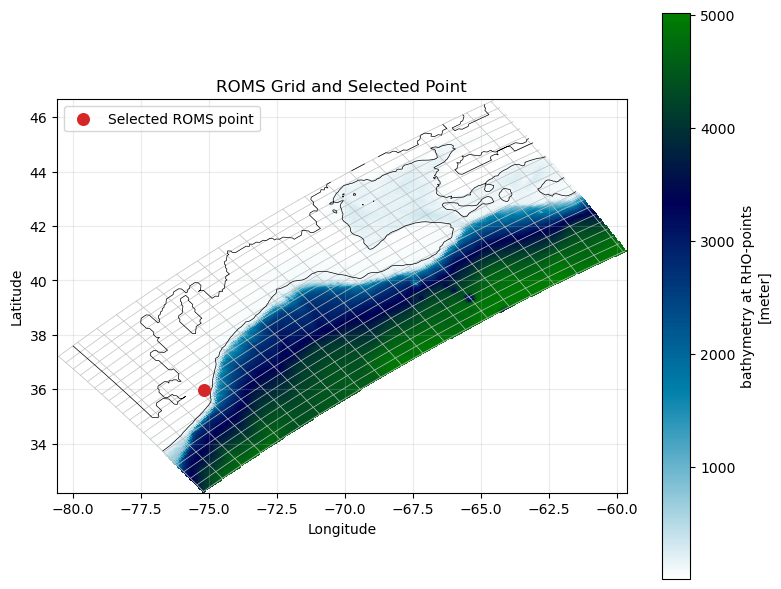

In [28]:
# Simple map: ROMS grid + selected nearest point.
fig, ax = plt.subplots(figsize=(8, 6))

# Subsample grid lines to keep plotting light and readable.
step_eta = max(1, lat2d.shape[0] // 20)
step_xi = max(1, lat2d.shape[1] // 20)

for eta in range(0, lat2d.shape[0], step_eta):
    ax.plot(lon2d.isel(eta_rho=eta), lat2d.isel(eta_rho=eta), color='0.75', lw=0.5)
for xi in range(0, lon2d.shape[1], step_xi):
    ax.plot(lon2d.isel(xi_rho=xi), lat2d.isel(xi_rho=xi), color='0.75', lw=0.5)

ax.scatter(grid_lon, grid_lat, s=70, c='tab:red', marker='o', label='Selected ROMS point', zorder=3)

ds.h.plot.pcolormesh(x = 'lon_rho', y = 'lat_rho', cmap='ocean_r')
ds.h.plot.contour(x = 'lon_rho', y = 'lat_rho', colors='k', levels=[5, 100], linewidths=0.5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('ROMS Grid and Selected Point')
ax.legend(loc='best')
ax.grid(True, alpha=0.25)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [10]:
# Download time series of temperature at the nearest grid point and s_rho level.
df_temp = ds['temp'].sel(time=slice('2025-03-01', '2025-04-01'), s_rho=s_rho_idx, eta_rho=eta_idx, xi_rho=xi_idx)
df_temp


<xarray.DataArray 'temp' (time: 768)> Size: 6kB
[768 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 6kB 2025-03-01 ... 2025-04-01T23:00:00
    time_run  (time) datetime64[ns] 6kB ...
    s_rho     float64 8B -0.9875
    lon_rho   float64 8B -75.16
    lat_rho   float64 8B 35.96
Attributes:
    units:          Celsius
    long_name:      potential temperature
    time:           ocean_time
    grid:           grid
    location:       face
    field:          temperature, scalar, series
    _ChunkSizes:    [  1  20  53 121]
    standard_name:  sea_water_potential_temperature

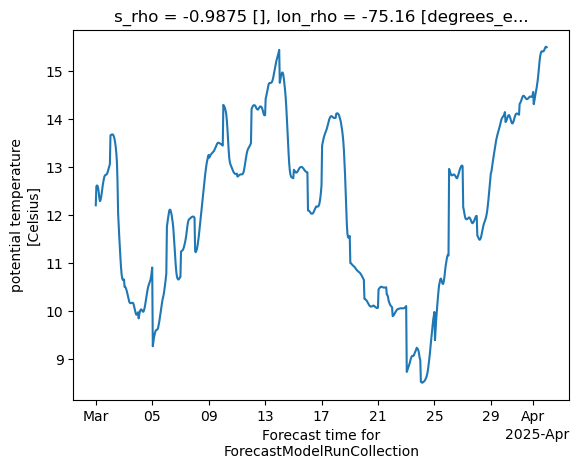

In [11]:
df_temp.plot()

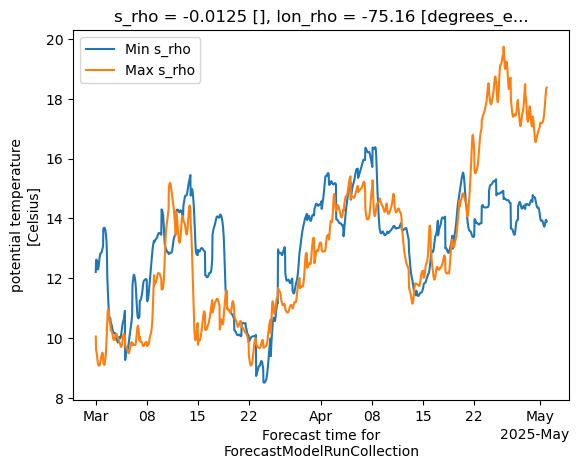

In [12]:
# Let's look at the top and bottom temperature time series at the same location.
ds_min = ds['temp'].sel(time=slice('2025-03-01', '2025-05-01'), s_rho=s_rho_idx_min, eta_rho=eta_idx, xi_rho=xi_idx)
ds_max = ds['temp'].sel(time=slice('2025-03-01', '2025-05-01'), s_rho=s_rho_idx_max, eta_rho=eta_idx, xi_rho=xi_idx)

ds_min.plot(label='Min s_rho')
ds_max.plot(label='Max s_rho')

plt.legend()

## Combined OOI and ROMS Plot

In [13]:
start_time = '2025-03-01'
end_time = '2025-05-01'

ds_temp_min = ds['temp'].sel(time=slice(start_time, end_time), s_rho=ds['s_rho'].min(), eta_rho=eta_idx, xi_rho=xi_idx).load()
ds_temp_max = ds['temp'].sel(time=slice(start_time, end_time), s_rho=ds['s_rho'].max(), eta_rho=eta_idx, xi_rho=xi_idx).load()

ds_salt_min = ds['salt'].sel(time=slice(start_time, end_time), s_rho=ds['s_rho'].min(), eta_rho=eta_idx, xi_rho=xi_idx).load()
ds_salt_max = ds['salt'].sel(time=slice(start_time, end_time), s_rho=ds['s_rho'].max(), eta_rho=eta_idx, xi_rho=xi_idx).load()

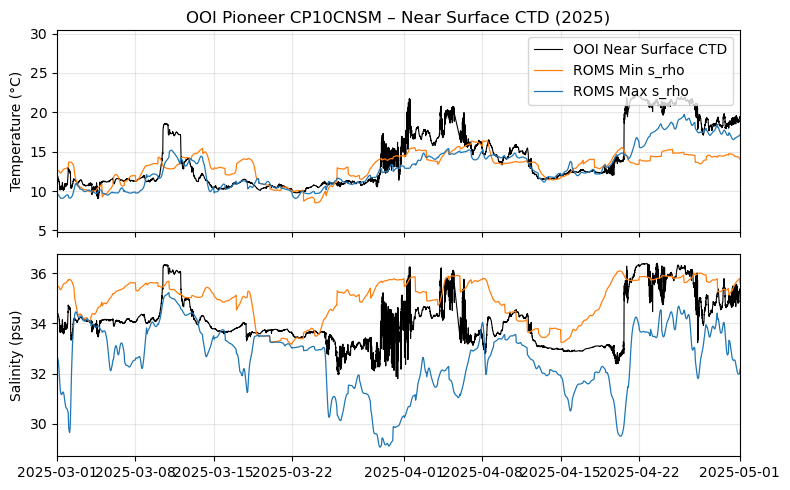

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(df_ooi.index, df_ooi['sea_water_temperature'], color='k', lw=0.8, label='OOI Near Surface CTD')
axes[0].plot(ds_temp_min.time, ds_temp_min.values, color='tab:orange', lw=0.9, label='ROMS Min s_rho')
axes[0].plot(ds_temp_max.time, ds_temp_max.values, color='tab:blue', lw=0.9, label='ROMS Max s_rho')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')
axes[0].set_title('OOI Pioneer CP10CNSM – Near Surface CTD (2025)')

axes[1].plot(df_ooi.index, df_ooi['sea_water_practical_salinity'], color='k', lw=0.8, label='OOI Near Surface CTD')
axes[1].plot(ds_salt_min.time, ds_salt_min.values, color='tab:orange', lw=0.9, label='ROMS Min s_rho')
axes[1].plot(ds_salt_max.time, ds_salt_max.values, color='tab:blue', lw=0.9, label='ROMS Max s_rho')
axes[1].set_ylabel('Salinity (psu)')
axes[1].grid(True, alpha=0.3)

axes[1].set_xlim([pd.to_datetime(start_time), pd.to_datetime(end_time)])

fig.tight_layout()
plt.show()

## ROMS Profile Timeseries

In [35]:
ds_profile_temp = ds['temp'].sel(time=slice('2025-03-01', '2025-05-01'), eta_rho=eta_idx, xi_rho=xi_idx)
ds_profile_sal = ds['salt'].sel(time=slice('2025-03-01', '2025-05-01'), eta_rho=eta_idx, xi_rho=xi_idx)

In [36]:
print(ds_profile_temp.nbytes/1e6, 'MB')  # Size in MB
print(ds_profile_sal.nbytes/1e6, 'MB')  # Size in MB

0.47616 MB
0.47616 MB


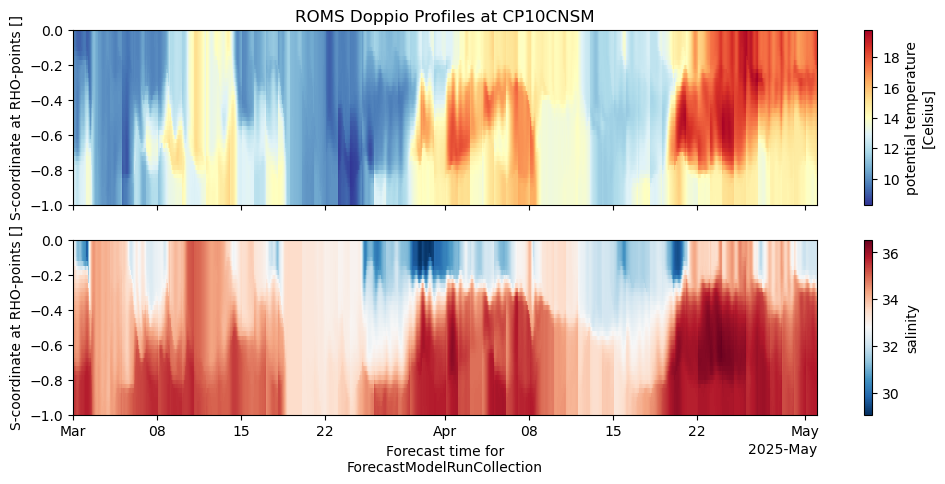

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ds_profile_temp.plot(y='s_rho', yincrease=False, ax=axes[0], cmap='RdYlBu_r', vmin=ds_profile_temp.min(), vmax=ds_profile_temp.max())
ds_profile_sal.plot(y='s_rho', yincrease=False, ax=axes[1], cmap='RdBu_r', vmin=ds_profile_sal.min(), vmax=ds_profile_sal.max())

axes[0].invert_yaxis()
axes[1].invert_yaxis()

axes[0].set_title('ROMS Doppio Profiles at CP10CNSM')
axes[0].set_xlabel('')
axes[1].set_title('');

## Benchmark testing

In [18]:
import time

import pandas as pd

# Benchmark settings
end = pd.Timestamp("2025-04-01")
windows = [
    ("1 day", pd.Timedelta(days=1)),
    ("1 week", pd.Timedelta(weeks=1)),
    ("2 weeks", pd.Timedelta(weeks=2)),
    ("1 month", pd.DateOffset(months=1)),
    ("2 months", pd.DateOffset(months=2)),
    ("3 months", pd.DateOffset(months=3)),
    # ("6 months", pd.DateOffset(months=6)),
    # ("9 months", pd.DateOffset(months=9)),
    # ("12 months", pd.DateOffset(months=12)),
]

rows = []
n_windows = len(windows)

print(f"Starting benchmark: {n_windows} windows, 1 run each")
print("Comparing: single-point (fixed s_rho) vs full profile (all s_rho)")

for i, (label, delta) in enumerate(windows, start=1):
    start = end - delta

    print(f"\n[{i}/{n_windows}] Window: {label} ({start:%Y-%m-%d} to {end:%Y-%m-%d})")

    t0 = time.perf_counter()
    arr_point = ds["temp"].sel(
        time=slice(start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")),
        s_rho=ds["s_rho"].min(),
        eta_rho=eta_idx,
        xi_rho=xi_idx,
    ).load()
    point_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    arr_profile = ds["temp"].sel(
        time=slice(start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")),
        eta_rho=eta_idx,
        xi_rho=xi_idx,
    ).load()
    profile_s = time.perf_counter() - t1

    n_time = arr_point.sizes.get("time", None)
    n_levels = arr_profile.sizes.get("s_rho", None)

    point_bytes = int(arr_point.nbytes)
    profile_bytes = int(arr_profile.nbytes)

    profile_over_point_time = (profile_s / point_s) if point_s > 0 else float("nan")
    profile_over_point_size = (profile_bytes / point_bytes) if point_bytes > 0 else float("nan")

    rows.append(
        {
            "window": label,
            "months": (end.to_period("M") - start.to_period("M")).n + (0 if label in ["1 day", "1 week"] else 0),
            "start": start.strftime("%Y-%m-%d"),
            "end": end.strftime("%Y-%m-%d"),
            "n_time": n_time,
            "n_levels": n_levels,
            "point_s": point_s,
            "profile_s": profile_s,
            "profile_over_point_time": profile_over_point_time,
            "point_bytes": point_bytes,
            "profile_bytes": profile_bytes,
            "point_mb": point_bytes / 1e6,
            "profile_mb": profile_bytes / 1e6,
            "profile_over_point_size": profile_over_point_size,
        }
    )

    print(
        f"  point={point_s:.4f}s ({point_bytes/1e6:.3f} MB), "
        f"profile={profile_s:.4f}s ({profile_bytes/1e6:.3f} MB), "
        f"time ratio={profile_over_point_time:.2f}x, "
        f"size ratio={profile_over_point_size:.2f}x"
    )

bench = pd.DataFrame(rows)

print("\nRun complete. Use next cells for analysis table and plot.")

Starting benchmark: 6 windows, 1 run each
Comparing: single-point (fixed s_rho) vs full profile (all s_rho)

[1/6] Window: 1 day (2025-03-31 to 2025-04-01)
  point=0.4166s (0.000 MB), profile=0.6520s (0.015 MB), time ratio=1.56x, size ratio=40.00x

[2/6] Window: 1 week (2025-03-25 to 2025-04-01)
  point=1.1561s (0.002 MB), profile=2.0772s (0.061 MB), time ratio=1.80x, size ratio=40.00x

[3/6] Window: 2 weeks (2025-03-18 to 2025-04-01)
  point=2.0123s (0.003 MB), profile=3.7266s (0.115 MB), time ratio=1.85x, size ratio=40.00x

[4/6] Window: 1 month (2025-03-01 to 2025-04-01)
  point=4.0658s (0.006 MB), profile=7.7618s (0.246 MB), time ratio=1.91x, size ratio=40.00x

[5/6] Window: 2 months (2025-02-01 to 2025-04-01)
  point=7.4642s (0.012 MB), profile=14.3866s (0.461 MB), time ratio=1.93x, size ratio=40.00x

[6/6] Window: 3 months (2025-01-01 to 2025-04-01)
  point=11.2091s (0.017 MB), profile=21.7711s (0.699 MB), time ratio=1.94x, size ratio=40.00x

Run complete. Use next cells for anal

In [19]:
# Analysis table
order = {
    "1 day": 0,
    "1 week": 1,
    "2 weeks": 2,
    "1 month": 3,
    "2 months": 4,
    "3 months": 5,
    "6 months": 6,
    "9 months": 7,
    "12 months": 8,
}
bench_sorted = bench.sort_values("window", key=lambda s: s.map(order)).reset_index(drop=True)

bench_display = bench_sorted.copy()
for col in [
    "point_s", "profile_s",
    "profile_over_point_time",
    "point_mb", "profile_mb", "profile_over_point_size",
]:
    bench_display[col] = bench_display[col].map(lambda x: round(x, 4))

display(
    bench_display[[
        "window", "start", "end", "n_time", "n_levels",
        "point_s", "profile_s", "profile_over_point_time",
        "point_mb", "profile_mb", "profile_over_point_size",
    ]]
)

,window,start,end,n_time,n_levels,point_s,profile_s,profile_over_point_time,point_mb,profile_mb,profile_over_point_size
0,1 day,2025-03-31,2025-04-01,48,40,0.4166,0.6520,1.5648,0.0004,0.0154,40.0
1,1 week,2025-03-25,2025-04-01,192,40,1.1561,2.0772,1.7966,0.0015,0.0614,40.0
2,2 weeks,2025-03-18,2025-04-01,360,40,2.0123,3.7266,1.8519,0.0029,0.1152,40.0
3,1 month,2025-03-01,2025-04-01,768,40,4.0658,7.7618,1.9091,0.0061,0.2458,40.0
4,2 months,2025-02-01,2025-04-01,1440,40,7.4642,14.3866,1.9274,0.0115,0.4608,40.0
5,3 months,2025-01-01,2025-04-01,2184,40,11.2091,21.7711,1.9423,0.0175,0.6989,40.0


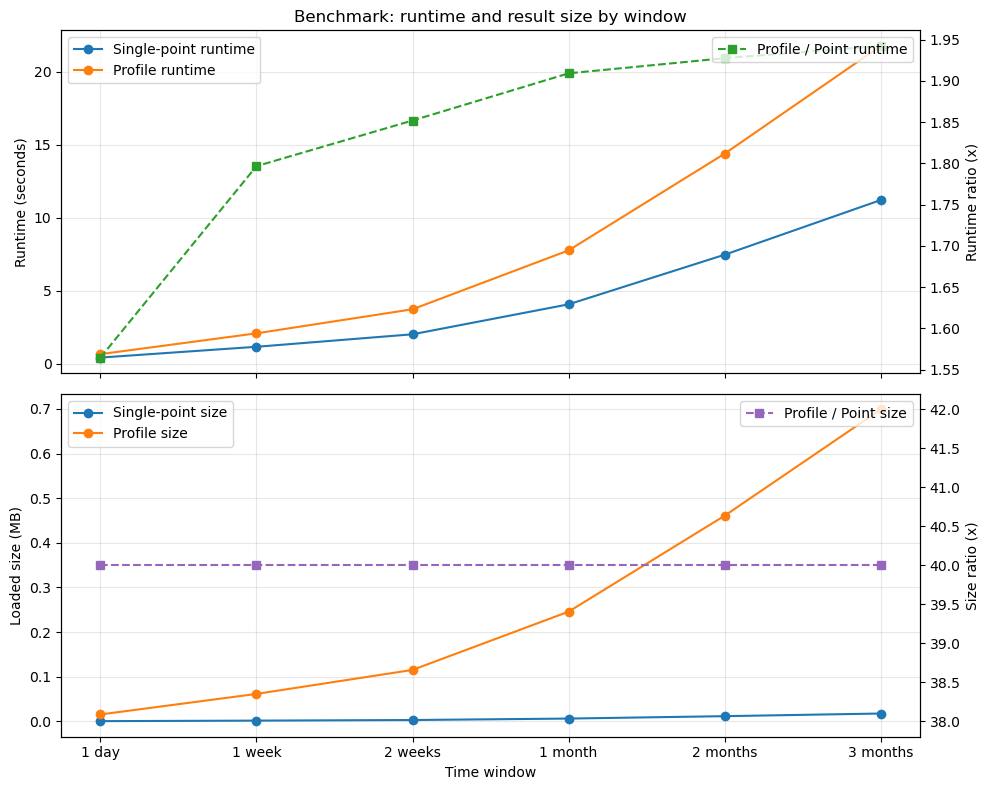

In [20]:
import matplotlib.pyplot as plt

order = {
    "1 day": 0,
    "1 week": 1,
    "2 weeks": 2,
    "1 month": 3,
    "2 months": 4,
    "3 months": 5,
    "6 months": 6,
    "9 months": 7,
    "12 months": 8,
}
bench_plot = bench.sort_values("window", key=lambda s: s.map(order)).reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Runtime comparison
axes[0].plot(bench_plot["window"], bench_plot["point_s"], marker="o", label="Single-point runtime")
axes[0].plot(bench_plot["window"], bench_plot["profile_s"], marker="o", label="Profile runtime")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Benchmark: runtime and result size by window")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper left")

ax0r = axes[0].twinx()
ax0r.plot(
    bench_plot["window"],
    bench_plot["profile_over_point_time"],
    marker="s",
    linestyle="--",
    color="tab:green",
    label="Profile / Point runtime",
)
ax0r.set_ylabel("Runtime ratio (x)")
ax0r.legend(loc="upper right")

# Size comparison
axes[1].plot(bench_plot["window"], bench_plot["point_mb"], marker="o", label="Single-point size")
axes[1].plot(bench_plot["window"], bench_plot["profile_mb"], marker="o", label="Profile size")
axes[1].set_ylabel("Loaded size (MB)")
axes[1].set_xlabel("Time window")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper left")

ax1r = axes[1].twinx()
ax1r.plot(
    bench_plot["window"],
    bench_plot["profile_over_point_size"],
    marker="s",
    linestyle="--",
    color="tab:purple",
    label="Profile / Point size",
)
ax1r.set_ylabel("Size ratio (x)")
ax1r.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Sequential load test

In [21]:
import time
import numpy as np
import pandas as pd
import xarray as xr

# Compare load strategies over a configurable time window at the selected ROMS point.
test_start = pd.Timestamp("2025-01-01")
test_end = pd.Timestamp("2025-04-01")

# Configure chunk plans here. Use None for one-shot load.
# Examples: "5D", "10D", "2W", "MS", "2MS", pd.Timedelta(days=3)
chunk_plan = [
    ("all_at_once", None),
    ("monthly_chunks", "MS"),
    ("5day_chunks", "5D"),
    ("1day_chunks", "1D"),
]

print(f"Chunking test window: {test_start:%Y-%m-%d} to {test_end:%Y-%m-%d} ({(test_end - test_start).days} days)")

def load_temp_profile(start_ts, end_ts):
    return ds["temp"].sel(
        time=slice(start_ts.strftime("%Y-%m-%d"), end_ts.strftime("%Y-%m-%d")),
        eta_rho=eta_idx,
        xi_rho=xi_idx,
    ).load()

def build_ranges(start_ts, end_ts, chunk_spec):
    if chunk_spec is None:
        return [(start_ts, end_ts)]

    boundaries = pd.date_range(start=start_ts, end=end_ts, freq=chunk_spec)
    if len(boundaries) == 0 or boundaries[0] != start_ts:
        boundaries = boundaries.insert(0, start_ts)
    if boundaries[-1] != end_ts:
        boundaries = boundaries.insert(len(boundaries), end_ts)

    return list(zip(boundaries[:-1], boundaries[1:]))

def run_strategy(label, ranges):
    chunk_times = []
    pieces = []
    print(f"\nRunning strategy: {label} ({len(ranges)} chunk(s))")

    t0_total = time.perf_counter()
    for idx, (chunk_start, chunk_end) in enumerate(ranges, start=1):
        print(f"  chunk {idx}/{len(ranges)}: {chunk_start:%Y-%m-%d} to {chunk_end:%Y-%m-%d}")
        t0_chunk = time.perf_counter()
        pieces.append(load_temp_profile(chunk_start, chunk_end))
        chunk_times.append(time.perf_counter() - t0_chunk)

    if len(pieces) == 1:
        result = pieces[0]
    else:
        result = xr.concat(pieces, dim="time").sortby("time")
        _, unique_idx = np.unique(result["time"].values, return_index=True)
        result = result.isel(time=np.sort(unique_idx))

    total_s = time.perf_counter() - t0_total
    chunk_mean_s = float(np.mean(chunk_times))
    chunk_std_s = float(np.std(chunk_times)) if len(chunk_times) > 1 else 0.0
    size_mb = result.nbytes / 1e6

    print(
        f"  done: total={total_s:.3f}s, "
        f"chunk_mean={chunk_mean_s:.3f}s, chunk_std={chunk_std_s:.3f}s, "
        f"size={size_mb:.3f} MB"
    )

    return {
        "strategy": label,
        "total_s": total_s,
        "chunk_mean_s": chunk_mean_s,
        "chunk_std_s": chunk_std_s,
        "size_mb": size_mb,
    }, result

summary_rows = []
results_by_strategy = {}

for strategy_label, chunk_spec in chunk_plan:
    ranges = build_ranges(test_start, test_end, chunk_spec)
    row, arr = run_strategy(strategy_label, ranges)
    summary_rows.append(row)
    results_by_strategy[strategy_label] = arr

chunk_compare = pd.DataFrame(summary_rows).sort_values("strategy").reset_index(drop=True)

print("\nRun complete. Use next cells for analysis table and plot.")

Chunking test window: 2025-01-01 to 2025-04-01 (90 days)

Running strategy: all_at_once (1 chunk(s))
  chunk 1/1: 2025-01-01 to 2025-04-01
  done: total=21.743s, chunk_mean=21.743s, chunk_std=0.000s, size=0.699 MB

Running strategy: monthly_chunks (3 chunk(s))
  chunk 1/3: 2025-01-01 to 2025-02-01
  chunk 2/3: 2025-02-01 to 2025-03-01
  chunk 3/3: 2025-03-01 to 2025-04-01
  done: total=22.522s, chunk_mean=7.506s, chunk_std=0.333s, size=0.699 MB

Running strategy: 5day_chunks (18 chunk(s))
  chunk 1/18: 2025-01-01 to 2025-01-06
  chunk 2/18: 2025-01-06 to 2025-01-11
  chunk 3/18: 2025-01-11 to 2025-01-16
  chunk 4/18: 2025-01-16 to 2025-01-21
  chunk 5/18: 2025-01-21 to 2025-01-26
  chunk 6/18: 2025-01-26 to 2025-01-31
  chunk 7/18: 2025-01-31 to 2025-02-05
  chunk 8/18: 2025-02-05 to 2025-02-10
  chunk 9/18: 2025-02-10 to 2025-02-15
  chunk 10/18: 2025-02-15 to 2025-02-20
  chunk 11/18: 2025-02-20 to 2025-02-25
  chunk 12/18: 2025-02-25 to 2025-03-02
  chunk 13/18: 2025-03-02 to 2025-0

In [22]:
# Analysis table
display(
    chunk_compare[["strategy", "total_s", "chunk_mean_s", "chunk_std_s", "size_mb"]].round(4)
)

,strategy,total_s,chunk_mean_s,chunk_std_s,size_mb
0,1day_chunks,58.4637,0.6491,0.0052,0.6989
1,5day_chunks,28.7833,1.5985,0.0089,0.6989
2,all_at_once,21.7432,21.7432,0.0000,0.6989
3,monthly_chunks,22.5218,7.5062,0.3328,0.6989


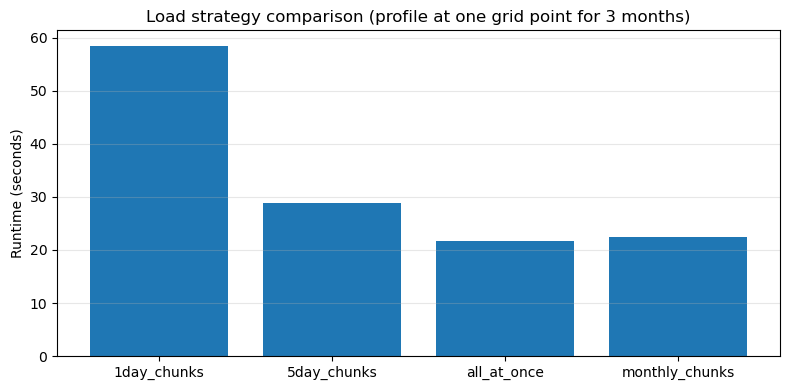

In [24]:
import matplotlib.pyplot as plt

# Timing plot
plt.figure(figsize=(8, 4))
plt.bar(chunk_compare["strategy"], chunk_compare["total_s"])
plt.ylabel("Runtime (seconds)")
plt.title("Load strategy comparison (profile at one grid point for 3 months)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()